# Análisis Exploratorio de Datos — UNSW-NB15

## 0. Dependencias

In [5]:
%pip install pandas numpy matplotlib kagglehub

Note: you may need to restart the kernel to use updated packages.


## 1. Configuración y carga de datos

In [6]:
import shutil
from pathlib import Path
from matplotlib.patches import Patch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

DATA_DIR = Path('dataset') if Path('dataset').is_dir() else Path('../dataset')

AZUL, ROJO = '#2e86c1', '#c0392b'
plt.rc('font', size=10)

In [7]:
KAGGLE_DATASET = 'harshwardhanbhangale/unsw-complete-dataset'
REQ = [f'UNSW-NB15_{i}.csv' for i in range(1, 5)]
if all((DATA_DIR / f).exists() for f in REQ):
    print('Dataset ya presente en', DATA_DIR)
else:
    print('Descargando dataset desde Kaggle...')
    import kagglehub
    tmp = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for f in REQ:
        origen = tmp / f
        if origen.exists():
            shutil.copy2(origen, DATA_DIR / f)
            print('  ->', f)

COLUMNS = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state',
    'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss',
    'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin',
    'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len',
    'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt',
    'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
    'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src',
    'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label',
]

DTYPES = {
    'srcip': 'string', 'dstip': 'string', 'proto': 'string',
    'state': 'string', 'service': 'string', 'attack_cat': 'string',
    'sport': 'Int32', 'dsport': 'Int32', 'sbytes': 'Int32', 'dbytes': 'Int32',
    'sttl': 'Int16', 'dttl': 'Int16', 'sloss': 'Int16', 'dloss': 'Int16',
    'Spkts': 'Int16', 'Dpkts': 'Int16', 'swin': 'Int16', 'dwin': 'Int16',
    'stcpb': 'Int64', 'dtcpb': 'Int64', 'smeansz': 'Int16', 'dmeansz': 'Int16',
    'trans_depth': 'Int16', 'res_bdy_len': 'Int32', 'Stime': 'Int32', 'Ltime': 'Int32',
    'ct_state_ttl': 'Int8', 'ct_flw_http_mthd': 'Int8', 'ct_ftp_cmd': 'Int8',
    'ct_srv_src': 'Int8', 'ct_srv_dst': 'Int8', 'ct_dst_ltm': 'Int8',
    'ct_src_ ltm': 'Int8', 'ct_src_dport_ltm': 'Int8', 'ct_dst_sport_ltm': 'Int8',
    'ct_dst_src_ltm': 'Int8',
    'dur': 'Float32', 'Sload': 'Float64', 'Dload': 'Float64',
    'Sjit': 'Float32', 'Djit': 'Float32', 'Sintpkt': 'Float32', 'Dintpkt': 'Float32',
    'tcprtt': 'Float32', 'synack': 'Float32', 'ackdat': 'Float32',
    'is_sm_ips_ports': 'boolean', 'is_ftp_login': 'boolean', 'Label': 'boolean',
}

NA_VALUES = {
    'sport': ['0x000b', '0x000c', '-'],
    'dsport': ['0xc0a8', '0xcc09', '0x20205321', '-'],
    'ct_ftp_cmd': [' '],
    'is_ftp_login': ['2', '4'],
    'state': ['no'],
}

ORIGEN = {
    'is_ftp_login': 'Estructural (FTP)',
    'ct_ftp_cmd': 'Estructural (FTP)',
    'ct_flw_http_mthd': 'Estructural (HTTP)',
    'dsport': 'Token corrupto',
    'sport': 'Token corrupto',
    'state': 'Token corrupto',
}

Dataset ya presente en ..\dataset


In [ ]:
# Lectura y concatenación de los 4 CSV
dfs = []
for i in range(1, 5):
    dfs.append(pd.read_csv(
        DATA_DIR / f'UNSW-NB15_{i}.csv',
        header=None, names=COLUMNS, dtype=DTYPES,
        na_values=NA_VALUES, low_memory=False,
    ))
df = pd.concat(dfs, ignore_index=True)
print(f'Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Shape: 2,540,047 filas x 49 columnas


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,<NA>,False
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,<NA>,False
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,<NA>,False
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,<NA>,False
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,<NA>,False


## 2. Definición del target multiclase

In [9]:
# Los registros sin attack_cat forman la categoría Benign (décima clase,
# se suma a las 9 familias de ataque)
df['attack_cat'] = (
    df['attack_cat'].fillna('Benign').str.strip().replace({'Backdoor': 'Backdoors'})
)

# Verificación: Benign <-> Label=0 (coincidencia 1:1)
inc_benigno_ataque = int(((df['attack_cat'] == 'Benign') & (df['Label'] == 1)).sum())
inc_ataque_benigno = int(((df['attack_cat'] != 'Benign') & (df['Label'] == 0)).sum())
if inc_benigno_ataque or inc_ataque_benigno:
    raise ValueError('attack_cat no se corresponde 1:1 con Label; revisar limpieza.')
print('Verificación target multiclase OK: Benign <-> Label=0 al 100%.')

for col in ['state', 'service', 'attack_cat']:
    df[col] = df[col].astype('category')

N = len(df)
df['attack_cat'].value_counts()

Verificación target multiclase OK: Benign <-> Label=0 al 100%.


attack_cat
Benign            2218764
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoors            2329
Shellcode            1511
Worms                 174
Name: count, dtype: int64

## 3. Utilidades

In [10]:
def _iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    if q3 - q1 == 0:
        return 0
    inf, sup = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    return int(((s < inf) | (s > sup)).sum())

def _eta2_num_cat(series, labels):
    s = series.astype('float64').dropna()
    lab = labels.loc[s.index]
    if lab.nunique(dropna=False) <= 1 or s.nunique() <= 1:
        return 0.0
    xbar = s.mean()
    ss_total = float(((s - xbar) ** 2).sum())
    ssb = float(
        lab.to_frame('y').assign(x=s).groupby('y')['x']
        .agg(['mean', 'count'])
        .assign(d=lambda t: t['count'] * (t['mean'] - xbar) ** 2)['d'].sum()
    )
    return ssb / ss_total if ss_total > 0 else 0.0


num_cols = df.select_dtypes(include=['number']).columns.tolist()

## 4. Tablas del informe

### T01 · Valores faltantes (`tab:faltantes`)

In [11]:
miss = df.isna().sum()
faltantes = pd.DataFrame({
    'columna': miss[miss > 0].index,
    'faltantes': miss[miss > 0].values,
    'origen': [ORIGEN[c] for c in miss[miss > 0].index],
})
faltantes['%'] = faltantes['faltantes'] / N * 100
faltantes = faltantes.sort_values('faltantes', ascending=False)
print(f'{len(faltantes)} columnas con faltantes · '
      f'{df.isna().any(axis=1).sum():,} filas afectadas '
      f'({df.isna().any(axis=1).mean() * 100:.2f}%)')
display(faltantes)

6 columnas con faltantes · 1,452,912 filas afectadas (57.20%)


,columna,faltantes,origen,%
4,is_ftp_login,1430065,Estructural (FTP),56.300730
5,ct_ftp_cmd,1429879,Estructural (FTP),56.293407
3,ct_flw_http_mthd,1348145,Estructural (HTTP),53.075593
1,dsport,304,Token corrupto,0.011968
0,sport,8,Token corrupto,0.000315
2,state,8,Token corrupto,0.000315


### T02 · Estadísticos descriptivos (`tab:descriptivos`)

In [12]:
filas_desc = []
for c in num_cols:
    s = df[c].astype('float64')
    filas_desc.append({
        'variable': c,
        'n': int(s.count()),
        'media': round(s.mean(), 4),
        'mediana': round(s.median(), 4),
        'varianza': round(s.var(), 4),
        'min': round(s.min(), 4),
        'max': round(s.max(), 4),
        '%_ceros': round(float((s == 0).mean() * 100), 2),
    })
descriptivos = pd.DataFrame(filas_desc)
display(descriptivos)

,variable,n,media,mediana,varianza,min,max,%_ceros
0,sport,2540039,3.053457e+04,3.168700e+04,4.178801e+08,0.000000e+00,6.553500e+04,2.13
1,dsport,2539743,1.123510e+04,8.000000e+01,3.399674e+08,0.000000e+00,6.553500e+04,2.13
2,dur,2540047,6.588000e-01,1.590000e-02,1.939037e+02,0.000000e+00,8.786638e+03,0.33
3,sbytes,2540047,4.339600e+03,1.470000e+03,3.181636e+09,0.000000e+00,1.435577e+07,0.00
4,dbytes,2540047,3.642759e+04,1.820000e+03,2.595193e+10,0.000000e+00,1.465753e+07,19.69
5,sttl,2540047,6.278200e+01,3.100000e+01,5.568557e+03,0.000000e+00,2.550000e+02,0.41
6,dttl,2540047,3.076680e+01,2.900000e+01,1.836199e+03,0.000000e+00,2.540000e+02,19.92
7,sloss,2540047,5.163900e+00,3.000000e+00,5.070187e+02,0.000000e+00,5.319000e+03,41.23
8,dloss,2540047,1.632940e+01,4.000000e+00,3.202965e+03,0.000000e+00,5.507000e+03,41.36
9,Sload,2540047,3.695645e+07,5.893038e+05,1.406699e+16,0.000000e+00,5.988000e+09,0.20


### T03 · Distribución de clases (`fig01` y texto)

In [13]:
vc = df['attack_cat'].value_counts()
clases = pd.DataFrame({'clase': vc.index, 'n': vc.values})
clases['%'] = clases['n'] / N * 100
display(clases)

,clase,n,%
0,Benign,2218764,87.351297
1,Generic,215481,8.483347
2,Exploits,44525,1.752920
3,Fuzzers,24246,0.954549
4,DoS,16353,0.643807
5,Reconnaissance,13987,0.550659
6,Analysis,2677,0.105392
7,Backdoors,2329,0.091691
8,Shellcode,1511,0.059487
9,Worms,174,0.006850


### T04 · Cardinalidad de nominales (`tab:cardinalidad`)

In [14]:
nominales = ['srcip', 'dstip', 'sport', 'dsport', 'proto', 'state', 'service', 'attack_cat']
cardinalidad = pd.DataFrame({
    'columna': nominales,
    'unicos': [df[c].nunique(dropna=False) for c in nominales],
})
cardinalidad['%_unicos'] = cardinalidad['unicos'] / N * 100
cardinalidad = cardinalidad.sort_values('unicos', ascending=True)
constantes = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"Filas duplicadas: {int(df.duplicated().sum()):,} "
      f"({df.duplicated().mean() * 100:.2f}%) · columnas constantes: "
      f"{constantes or 'ninguna'}")
display(cardinalidad)

Filas duplicadas: 480,633 (18.92%) · columnas constantes: ninguna


,columna,unicos,%_unicos
7,attack_cat,10,0.000394
6,service,13,0.000512
5,state,16,0.000630
0,srcip,43,0.001693
1,dstip,47,0.001850
4,proto,135,0.005315
2,sport,64598,2.543181
3,dsport,64627,2.544323


### T05 · Outliers por IQR y % de ceros (`tab:outliers`)

In [15]:
filas_out = []
for c in num_cols:
    n = _iqr_outliers(df[c].astype('float64'))
    filas_out.append({
        'columna': c,
        'outliers_IQR': n,
        '%_outliers': round(n / N * 100, 2),
        '%_ceros': round(float((df[c] == 0).mean() * 100), 2),
    })
outliers = pd.DataFrame(filas_out).sort_values('outliers_IQR', ascending=False)
display(outliers)

,columna,outliers_IQR,%_outliers,%_ceros
9,Sload,563157,22.17,0.20
37,ct_src_dport_ltm,533566,21.01,0.00
21,Sjit,473263,18.63,37.93
26,Dintpkt,453642,17.86,19.71
2,dur,451297,17.77,0.33
25,Sintpkt,446036,17.56,0.06
39,ct_dst_src_ltm,415534,16.36,0.00
22,Djit,413969,16.30,35.43
35,ct_dst_ltm,362838,14.28,0.00
1,dsport,352582,13.88,2.13


### T06 · Razón de correlación η² vs `attack_cat` (`tab:eta`)

In [16]:
muestra = df.sample(n=500_000, random_state=42)
eta = pd.DataFrame({
    'columna': num_cols,
    'eta2': [_eta2_num_cat(muestra[c], muestra['attack_cat']) for c in num_cols],
}).sort_values('eta2', ascending=False)
display(eta)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33720\4247285894.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lab.to_frame('y').assign(x=s).groupby('y')['x']
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33720\4247285894.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lab.to_frame('y').assign(x=s).groupby('y')['x']
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_33720\4247285894.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence th

,columna,eta2
5,sttl,0.835449
30,ct_state_ttl,0.776751
39,ct_dst_src_ltm,0.323867
6,dttl,0.307288
38,ct_dst_sport_ltm,0.300834
34,ct_srv_dst,0.290180
33,ct_srv_src,0.283034
37,ct_src_dport_ltm,0.274438
35,ct_dst_ltm,0.237894
36,ct_src_ ltm,0.225531


## 5. Figuras del informe 

In [17]:
%matplotlib inline

def heatmap(mat, filas, col_etiquetas, titulo, cmap='RdBu_r', vmin=-1, vmax=1):
    fig, ax = plt.subplots(figsize=(max(7, 0.42 * len(filas)), max(5, 0.42 * len(filas))))
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(col_etiquetas)))
    ax.set_xticklabels(col_etiquetas, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(filas)))
    ax.set_yticklabels(filas, fontsize=8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(v) > 0.6 else 'black')
    fig.colorbar(im, ax=ax, label='correlación')
    ax.set_title(titulo)
    fig.tight_layout()
    return fig

### fig01 · Distribución del target (10 clases y zoom de ataques)

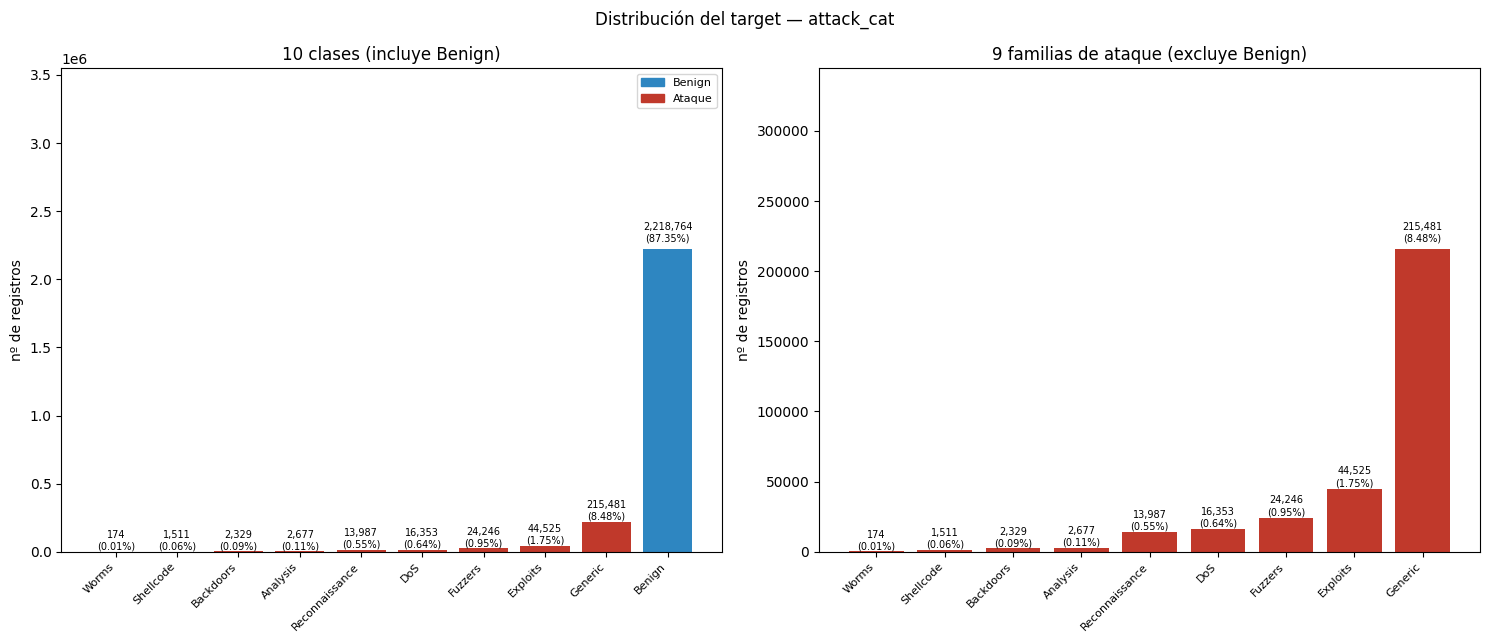

In [18]:
def _barras_clases(ax, s, titulo, leyenda=False):
    ax.bar(range(len(s)), s.values,
           color=[AZUL if c == 'Benign' else ROJO for c in s.index])
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(s.index, rotation=45, ha='right', fontsize=8)
    for x, (n, p) in enumerate(zip(s.values, s.values / N * 100)):
        ax.text(x, n * 1.02, f'{n:,}\n({p:.2f}%)',
                ha='center', va='bottom', fontsize=7)
    ax.set_ylabel('nº de registros')
    ax.set_title(titulo)
    ax.set_ylim(top=s.values.max() * 1.6)
    if leyenda:
        ax.legend(handles=[Patch(color=AZUL, label='Benign'),
                           Patch(color=ROJO, label='Ataque')], fontsize=8)

vc_asc = vc.sort_values(ascending=True)
ataq_asc = vc.drop(index=['Benign'], errors='ignore').sort_values(ascending=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))
_barras_clases(ax1, vc_asc, '10 clases (incluye Benign)', leyenda=True)
_barras_clases(ax2, ataq_asc, '9 familias de ataque (excluye Benign)')
fig.suptitle('Distribución del target — attack_cat')
fig.tight_layout()
plt.show()

### fig02 · Boxplots del top 9 por % de outliers

Top 9 variables por % de outliers: ['Sload', 'ct_src_dport_ltm', 'Sjit', 'Dintpkt', 'dur', 'Sintpkt', 'ct_dst_src_ltm', 'Djit', 'ct_dst_ltm']


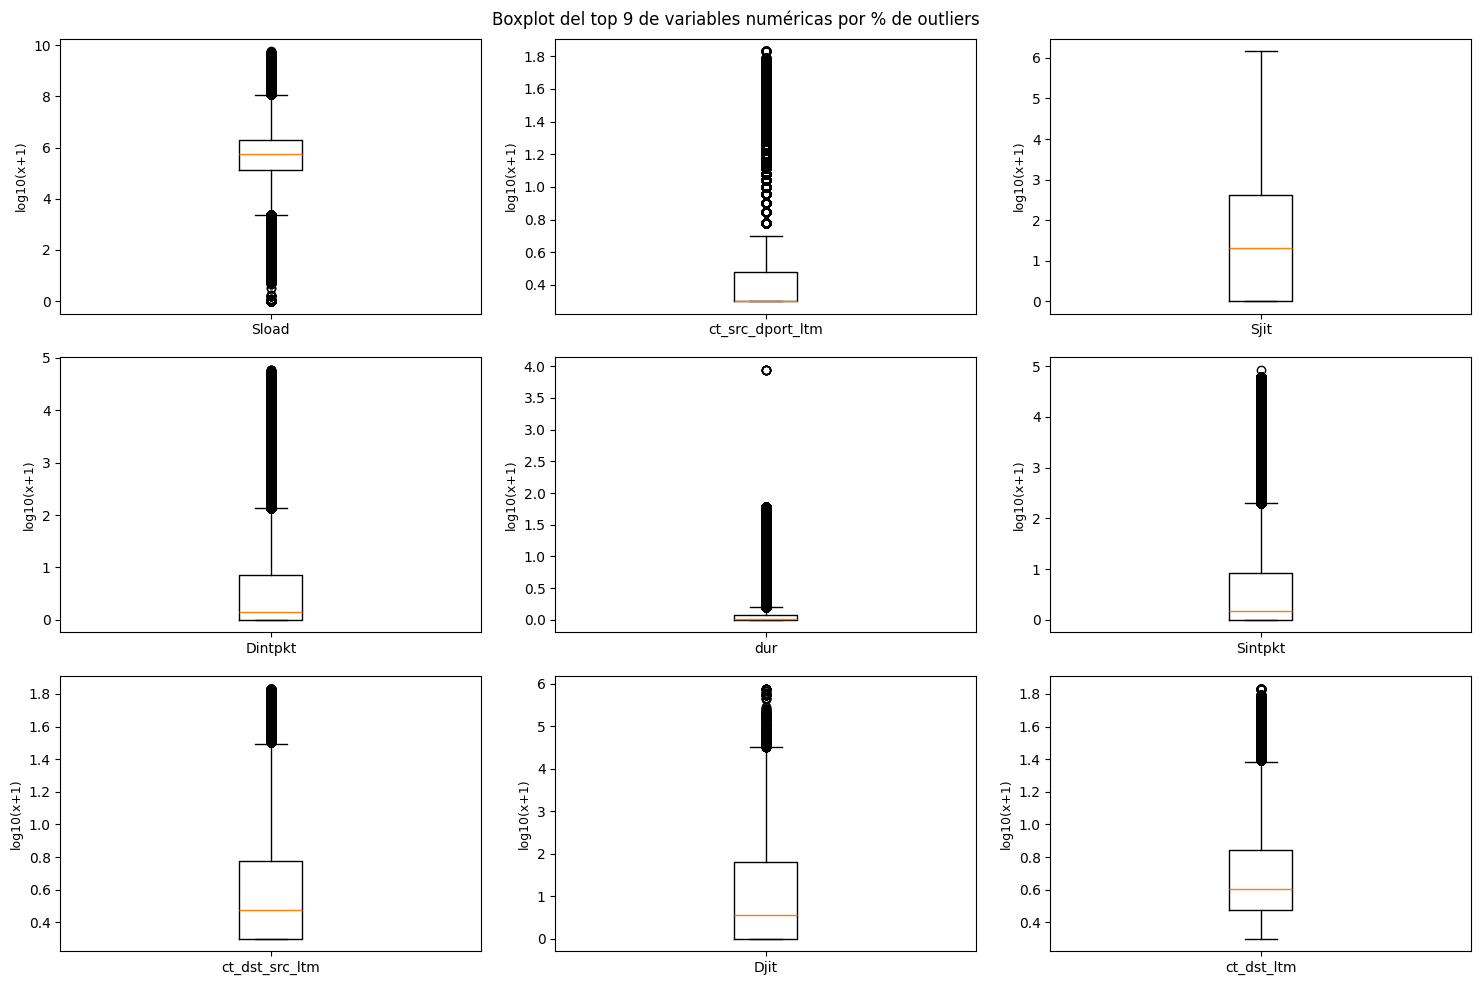

In [19]:
out_pct = pd.DataFrame({
    'columna': num_cols,
    '%': [_iqr_outliers(df[c].astype('float64')) / N * 100 for c in num_cols],
}).nlargest(9, '%')
top9 = out_pct['columna'].tolist()
print('Top 9 variables por % de outliers:', top9)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.ravel(), top9):
    datos = np.log10(df[col].astype('float64').dropna().to_numpy() + 1)
    ax.boxplot(datos, vert=True)
    ax.set_xticks([1])
    ax.set_xticklabels([col], fontsize=10)
    ax.set_ylabel('log10(x+1)', fontsize=9)
fig.suptitle('Boxplot del top 9 de variables numéricas por % de outliers')
fig.tight_layout()
plt.show()

### fig03 · Correlación de Pearson con el target binario

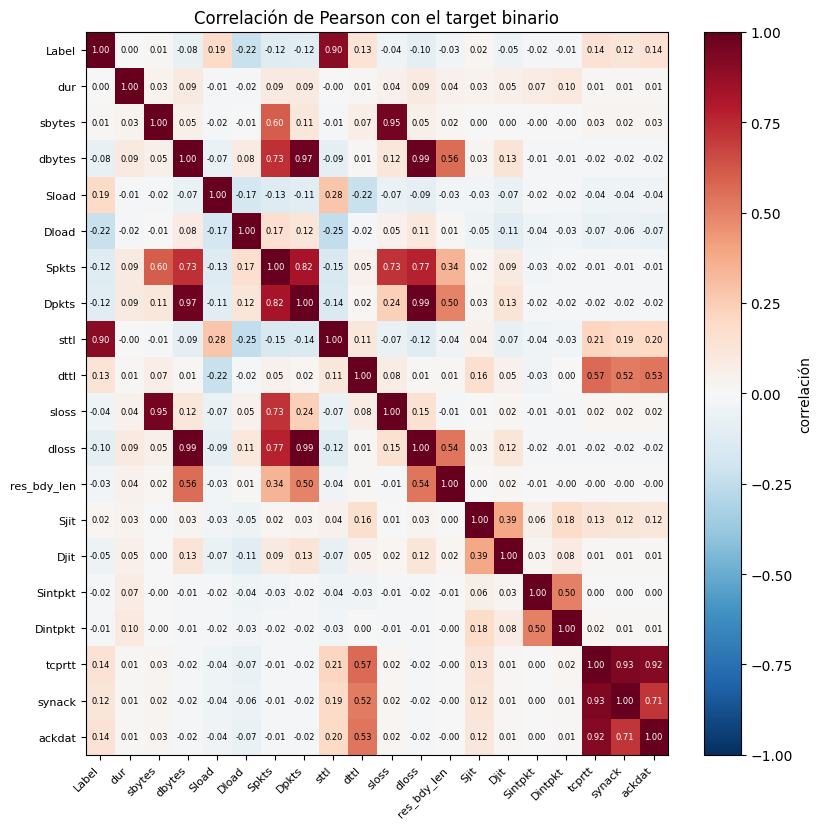

In [20]:
sel = ['dur', 'sbytes', 'dbytes', 'Sload', 'Dload', 'Spkts', 'Dpkts',
       'sttl', 'dttl', 'sloss', 'dloss', 'res_bdy_len', 'Sjit', 'Djit',
       'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat']
mat = df[['Label'] + sel].corr().values
fig = heatmap(mat, ['Label'] + sel, ['Label'] + sel,
              'Correlación de Pearson con el target binario')
plt.show()

### fig04 · Histogramas del top 9 por correlación con el target

Top 9 variables por correlación con Label: ['sttl', 'ct_state_ttl', 'ct_dst_src_ltm', 'ct_dst_sport_ltm', 'ct_src_dport_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_src_ ltm', 'ct_dst_ltm']


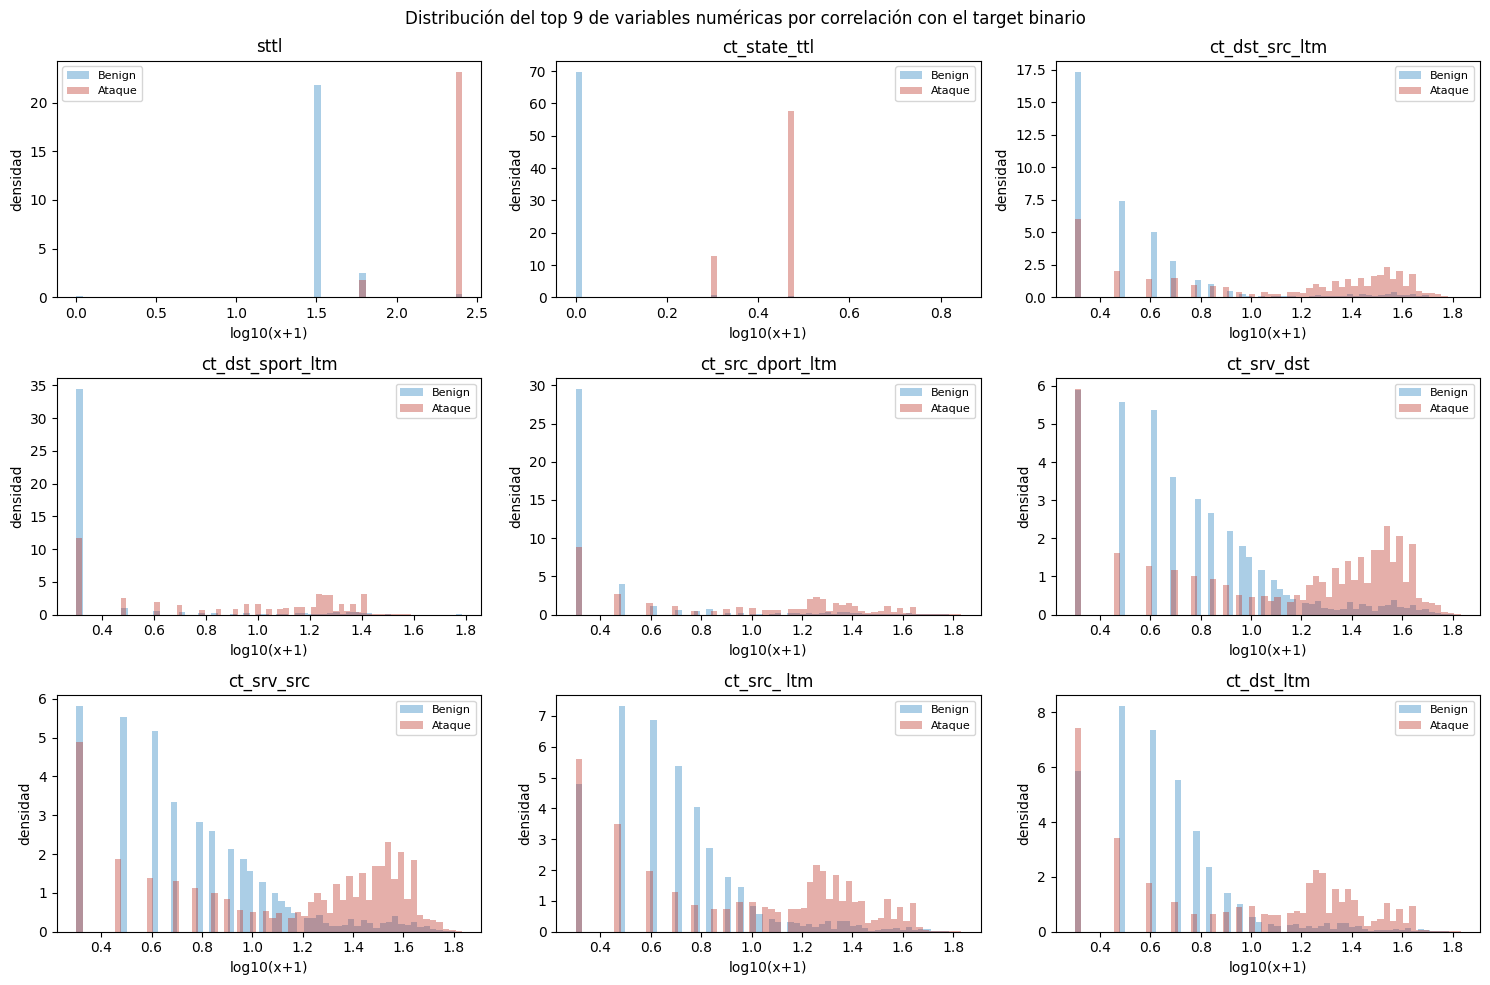

In [21]:
m_ben = df[df['attack_cat'] == 'Benign']
m_ataq = df[df['attack_cat'] != 'Benign']
corr_label = df[num_cols].corrwith(df['Label']).dropna().abs().sort_values(ascending=False)
top9_corr = corr_label.head(9).index.tolist()
print('Top 9 variables por correlación con Label:', top9_corr)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.ravel(), top9_corr):
    ax.hist(np.log10(m_ben[col].astype('float64') + 1), bins=60, alpha=0.4,
            label='Benign', color=AZUL, density=True)
    ax.hist(np.log10(m_ataq[col].astype('float64') + 1), bins=60, alpha=0.4,
            label='Ataque', color=ROJO, density=True)
    ax.set_title(col)
    ax.set_xlabel('log10(x+1)')
    ax.set_ylabel('densidad')
    ax.legend(fontsize=8)
fig.suptitle('Distribución del top 9 de variables numéricas por correlación con el target binario')
fig.tight_layout()
plt.show()

### fig05 · Correlación de las variables de ventana `ct_*` con el target

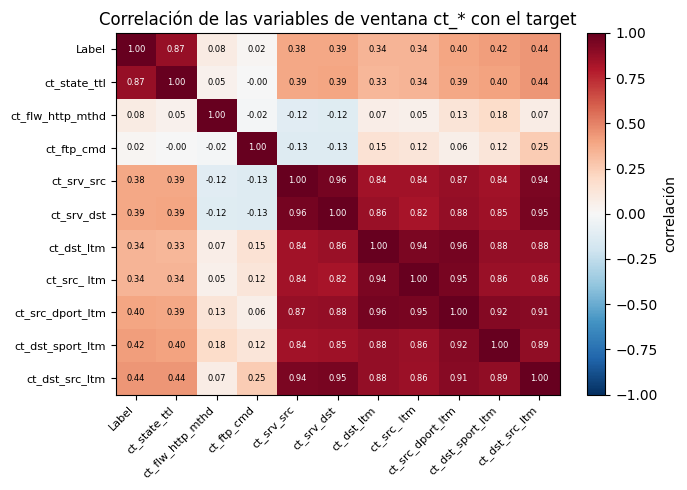

In [22]:
ct_cols = ['ct_state_ttl', 'ct_flw_http_mthd', 'ct_ftp_cmd', 'ct_srv_src',
           'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm',
           'ct_dst_sport_ltm', 'ct_dst_src_ltm']
mat = df[['Label'] + ct_cols].corr().values
fig = heatmap(mat, ['Label'] + ct_cols, ['Label'] + ct_cols,
              'Correlación de las variables de ventana ct_* con el target')
plt.show()